Published on June 31, 2026. By Prata, Marília (mpwolke)

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#Two lines Required to Plot Plotly
import plotly.io as pio
pio.renderers.default = 'iframe'

import plotly.graph_objs as go
import plotly.offline as py
import plotly.express as px

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


![](https://www.cyberdefinitions.com/IMT_images/NOMOPHOBIA_definition.jpg)

## NOMOPHOBIA: NO MObile PHone PhoBIA

Authors: Sudip Bhattacharya, Md Abu Bashar, Abhay Srivastava and Amarjeet Singh.

PMCID: PMC6510111  PMID: 31143710

"The term NOMOPHOBIA or **NO MObile PHone PhoBIA** is used to describe a psychological condition when people have a fear of being detached from mobile phone connectivity. The term NOMOPHOBIA is constructed on definitions described in the DSM-IV, it has been labelled as a “phobia for a particular/specific things”."

"Various psychological factors are involved when a person overuses the mobile phone, e.g., low self-esteem, extrovert personality. The burden of this problem is now increasing globally."

"Other mental disorders like, social phobia or social anxiety, and panic disorder may also precipitate NOMOPHOBIC symptoms. It is very difficult to differentiate whether the patient become NOMOPHOBIC due to mobile phone addiction or existing anxiety disorders manifest as NOMOPHOBIC symptoms." 

"The signs and symptoms are observed in NOMOPHOBIA cases include- anxiety, respiratory alterations, trembling, perspiration, agitation, disorientation and tachycardia. NOMOPHOBIA may also act as a proxy to other disorders. So, we have to be very judicious regarding its diagnosis."

"Some mental disorders can precipitate NOMOPHOBIA also and vice versa. The complexity of this condition is very challenging to the patients’ family members as well as for the physicians as NOMOPHOBIA shares common clinical symptoms with other disorders. That's why NOMOPHOBIA should be diagnosed by exclusion."

"We have to **stay in the real world more than virtual world**. We have to re-establish the human-human interactions, face to face connections. So, we need to limit our use of mobile phones rather than banning it because we cannot escape the force of technological advancement."

https://pmc.ncbi.nlm.nih.gov/articles/PMC6510111/

## Competition Citation

@misc{playground-series-s6e8,
    author = {Yao Yan, Walter Reade, Elizabeth Park},
    
    title = {Predicting Smartphone Addiction},
    year = {2026},
    
    howpublished = {\url{https://kaggle.com/competitions/playground-series-s6e8}},
    note = {Kaggle}
}

In [3]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')
sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv')

In [3]:
train.tail(3)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1
691368,691368,21.0,5.64,1.03,3.05,1.01,4.91,169.0,NaN,9.47,Other,Medium,Yes,0


In [17]:
train.columns.tolist()

['id',
 'age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'gender',
 'stress_level',
 'academic_work_impact',
 'addicted_label']

In [4]:
sub.head(2)

,id,addicted_label
0,691369,0.709424
1,691370,0.709424


## info() method

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [21]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       296302 non-null  int64  
 1   age                      279164 non-null  float64
 2   daily_screen_time_hours  263514 non-null  float64
 3   social_media_hours       248905 non-null  float64
 4   gaming_hours             236882 non-null  float64
 5   work_study_hours         268525 non-null  float64
 6   sleep_hours              273847 non-null  float64
 7   notifications_per_day    262081 non-null  float64
 8   app_opens_per_day        270597 non-null  float64
 9   weekend_screen_time      245605 non-null  float64
 10  gender                   282090 non-null  object 
 11  stress_level             276676 non-null  object 
 12  academic_work_impact     270581 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 29.4+ MB


### describe()

In [6]:
display(train, train.describe(include='all'))

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,662335,636221,647145,691369.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,High,Yes,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223662,220873,330566,NaN
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,NaN,NaN,NaN,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,NaN,NaN,NaN,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,NaN,NaN,NaN,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,NaN,NaN,NaN,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,NaN,NaN,NaN,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,NaN,NaN,NaN,1.000000


In [12]:
#By Cold https://www.kaggle.com/code/maulikgajera/scroll-sleep-suffer-the-student-addiction-loop/notebook

# ── Global plot style ──
PALETTE = ['#6C63FF', '#FF6B6B', '#48CAE4', '#F9C74F', '#90BE6D', '#F3722C', '#577590']
#BG_COLOR = '#0F0F1A'
TEXT_COLOR = '#E8E8F0'
GRID_COLOR = '#2A2A3E'

plt.rcParams.update({
    #'figure.facecolor'  : BG_COLOR,
    #'axes.facecolor'    : BG_COLOR,
    'axes.edgecolor'    : GRID_COLOR,
    'axes.labelcolor'   : TEXT_COLOR,
    'axes.titlecolor'   : TEXT_COLOR,
    'xtick.color'       : TEXT_COLOR,
    'ytick.color'       : TEXT_COLOR,
    'text.color'        : TEXT_COLOR,
    'grid.color'        : GRID_COLOR,
    'grid.linewidth'    : 0.6,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

### Trying some sophistication (By Maulik Gajera, aka Cold)

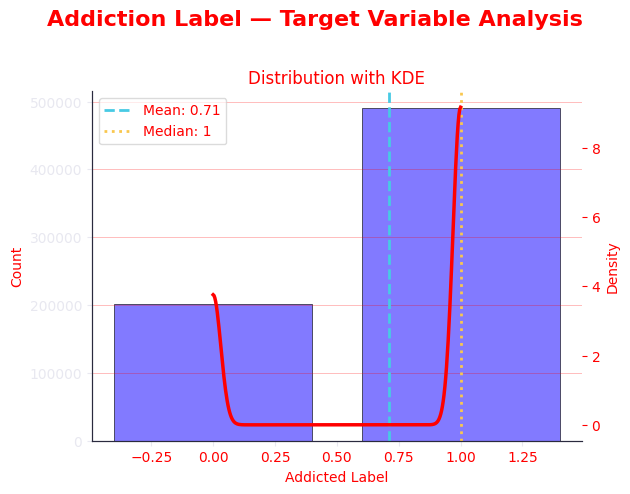


Shapiro-Wilk test: stat=0.5695, p=1.0994e-199
→ Distribution is NOT normal (as expected for a bounded ordinal scale)


In [13]:
#By Cold https://www.kaggle.com/code/maulikgajera/scroll-sleep-suffer-the-student-addiction-loop/notebook

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal

#fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig, axes = plt.subplots()
#fig, axes = plt.subplots(nrows=1, ncols=1, squeeze=False)
fig.suptitle('Addiction Label — Target Variable Analysis', color= 'red', fontsize=16, fontweight='bold', y=1.02)

# Left: Distribution with KDE
#ax = axes[0]
ax = axes
counts = train['addicted_label'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=PALETTE[0], alpha=0.85, edgecolor='black', linewidth=0.5)
ax2 = ax.twinx()
kde_x = np.linspace(train['addicted_label'].min(), train['addicted_label'].max(), 300)
kde = stats.gaussian_kde(train['addicted_label'])
ax2.plot(kde_x, kde(kde_x), color='r', linewidth=2.5, label='KDE')
ax2.set_ylabel('Density', color='r')
ax2.tick_params(color='r')
ax2.spines['top'].set_visible(False)
ax2.yaxis.label.set_color(color='r')
ax.set_xlabel('Addicted Label', color='red')
ax.set_ylabel('Count', color='r')
ax.set_title('Distribution with KDE', color='red')
ax.grid(axis='y', alpha=0.3, color='r')

# Add mean/median lines
ax.axvline(train['addicted_label'].mean(), color=PALETTE[2], linestyle='--', linewidth=2, label=f'Mean: {train["addicted_label"].mean():.2f}')
ax.axvline(train['addicted_label'].median(), color=PALETTE[3], linestyle=':', linewidth=2, label=f'Median: {train["addicted_label"].median():.0f}')
ax.legend(labelcolor= 'red', framealpha=0.7) #Added color just to the words/numbers

#ax.legend(facecolor= 'red', framealpha=0.7) #Add red to the whole rectangle with mean/median

#plt.tick_params(axis='x', labelcolor='red')#Didn't change anything 
plt.tick_params(axis='y', labelcolor='red')# Added color to numbers on right y

ax.tick_params(axis='x', labelcolor='red')#Changed numbers color x axis

plt.tight_layout()
plt.savefig('target_dist.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.savefig('target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk normality test
stat, p = stats.shapiro(train['addicted_label'])
print(f'\nShapiro-Wilk test: stat={stat:.4f}, p={p:.4e}')
print('→ Distribution is NOT normal (as expected for a bounded ordinal scale)' if p < 0.05 else '→ Cannot reject normality')

## Heatmap

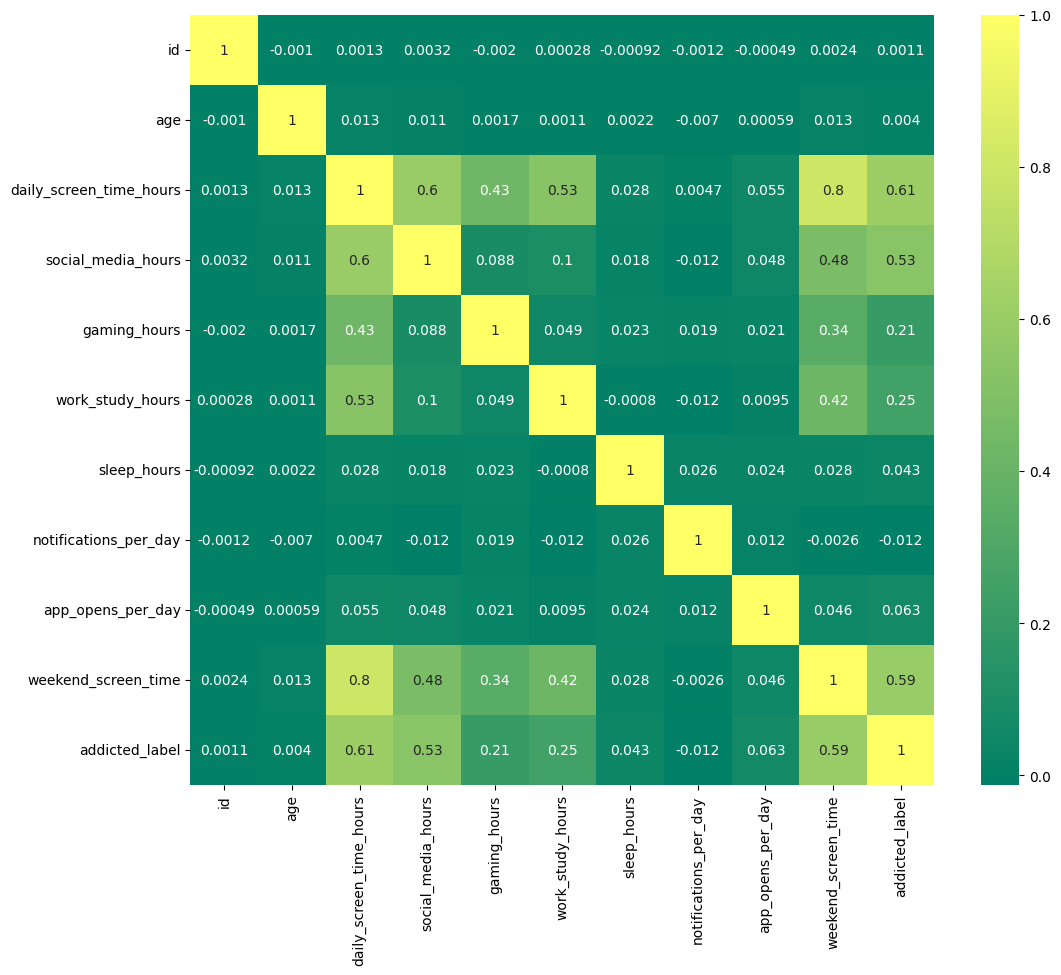

In [7]:
plt.figure(figsize=(12,10))
sns.heatmap(train.select_dtypes(include='number').corr(), annot=True, cmap='summer');

## Data insight

In [9]:
#By Abhinab SM Chhetri https://www.kaggle.com/code/abhinabbudhachheri/s6e2-simple-eda/notebook

def simple_insight(df):
    data = []
    for col in train.columns:
        top_val = train[col].mode()[0]
        freq = train[col].value_counts().iloc[0]

        pct = round((freq / len(train)) * 100, 1)

        uniq = train[col].nunique()
        miss = train[col].isnull().sum()

        data.append([col, uniq, top_val, pct, miss])
    res = pd.DataFrame(data, columns=['Column', 'Unique', 'Top Value', 'Dominance %', 'Missing'])
    return (res.style
            .bar(subset=['Dominance %', 'Unique'], color='#5fba7d')
            .format({'Dominance %': "{:.1f}%"})
           )

# Run it using your actual variable name 'train'
simple_insight(train)

,Column,Unique,Top Value,Dominance %,Missing
0,id,691369,0,0.0%,0
1,age,18,31.000000,6.3%,28929
2,daily_screen_time_hours,1389,7.210000,0.5%,95854
3,social_media_hours,721,1.890000,0.4%,133995
4,gaming_hours,401,0.710000,0.5%,126821
5,work_study_hours,600,1.530000,0.4%,51518
6,sleep_hours,451,7.770000,0.7%,44480
7,notifications_per_day,231,213.000000,1.4%,67584
8,app_opens_per_day,166,109.000000,1.6%,80710
9,weekend_screen_time,1437,7.670000,0.4%,112063


### Categorical features distribution

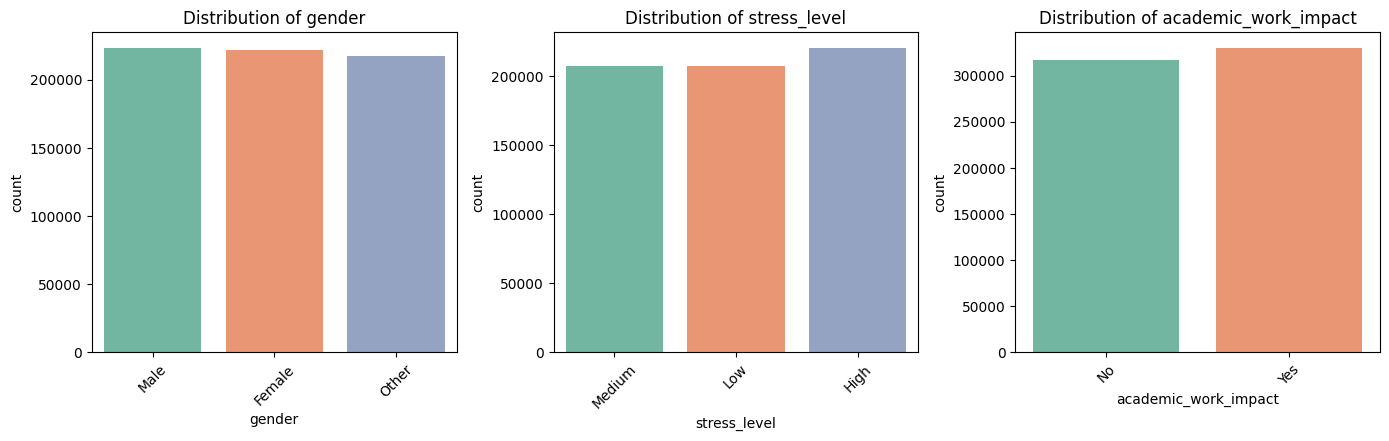

In [11]:
#By H-Z-Ning  https://www.kaggle.com/code/hzning/top-10-solution-0-97525-esay-is-all-you

categorical_columns = ["gender", "stress_level", "academic_work_impact"]

plt.figure(figsize=(14, 12))
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=column, data=train, palette='Set2')
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Handling missing values

In [8]:
#Sidney S. P. Bisssoli in R: https://rpubs.com/Bissoli/HousePrice
# columns where NaN values mean Not have that feature.
cols_fillna = ['gender', 'stress_level', 'academic_work_impact']

# replace 'NaN' with 'None' in these columns
for col in cols_fillna:
    train[col].fillna('None',inplace=True)
    test[col].fillna('None',inplace=True)

In [7]:
# Checking Numerical Data
train.select_dtypes(include=['int64','float64']).columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'addicted_label'],
      dtype='object')

## Attention numerical column can become object after fillna(0)

A numerical column can become an object data type after using .fillna(0) in Pandas because **newer versions of Pandas avoid silent downcasting or type inference**, or the column originally contained mixed data types or string representations of missing values.


### Filling numerical Nan

Filling All Numeric Columns at Once Select numeric data types:

train.fillna(train.select_dtypes(include='number').mean(), inplace=True)

Fill all numeric columns with zero: 

train[df.select_dtypes(include='number').columns] = df.select_dtypes(include='number').fillna(0)

In [6]:
train.fillna(train.select_dtypes(include='number').mean(), inplace=True)

## Import Libraries

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import optuna

## Label Encoding

In [11]:
#By Aryan_negi93 https://www.kaggle.com/code/aryannegi93/addiction-prediction-95-beats/notebook

LE = LabelEncoder()

In [12]:
train['gender'] = LE.fit_transform(train['gender'])
train['stress_level'] = LE.fit_transform(train['stress_level'])
train['academic_work_impact'] = LE.fit_transform(train['academic_work_impact'])

## Select X and y (target)

In [14]:
X = train.drop(columns=['id','addicted_label'])
y = train['addicted_label']

## train_test split

In [15]:
X_train , x_test , Y_train , y_test = train_test_split(X,y , test_size=0.2 , random_state=5)

In [16]:
#By Aryan_negi93 https://www.kaggle.com/code/aryannegi93/addiction-prediction-95-beats/notebook

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 30, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 10, 20),
    }
    model = XGBClassifier(**param , random_state=10)
    model.fit(X_train , Y_train)
    score = model.score(x_test,y_test)
    return score

## Optuna

In [17]:
#By Aryan_negi93 https://www.kaggle.com/code/aryannegi93/addiction-prediction-95-beats/notebook

study = optuna.create_study(direction='maximize')

[I 2026-08-01 01:28:56,331] A new study created in memory with name: no-name-c6626529-3d20-4a37-ba8b-a2e99427477b


### 50 Trials?? Really? Write 10 next time!!! Are you addicted?

In [18]:
study.optimize(objective , n_trials=50)

[I 2026-08-01 01:29:05,904] Trial 0 finished with value: 0.7886732140532566 and parameters: {'n_estimators': 243, 'max_depth': 3, 'learning_rate': 0.37668137568632526, 'scale_pos_weight': 18.205258596133845}. Best is trial 0 with value: 0.7886732140532566.
[I 2026-08-01 01:29:12,009] Trial 1 finished with value: 0.7996441847346573 and parameters: {'n_estimators': 390, 'max_depth': 3, 'learning_rate': 0.4799951477192837, 'scale_pos_weight': 18.534142820007105}. Best is trial 1 with value: 0.7996441847346573.
[I 2026-08-01 01:29:18,360] Trial 2 finished with value: 0.8299680344822599 and parameters: {'n_estimators': 251, 'max_depth': 6, 'learning_rate': 0.33765735827115106, 'scale_pos_weight': 13.273206603745223}. Best is trial 2 with value: 0.8299680344822599.
[I 2026-08-01 01:29:26,673] Trial 3 finished with value: 0.786380664477776 and parameters: {'n_estimators': 179, 'max_depth': 9, 'learning_rate': 0.02859222942016315, 'scale_pos_weight': 14.549609700146963}. Best is trial 2 with v

## Best trial and hyperparameters

In [19]:
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.8799774361051246
Best hyperparameters: {'n_estimators': 432, 'max_depth': 10, 'learning_rate': 0.4415894186857193, 'scale_pos_weight': 12.478944538225848}


## Final model

In [20]:
#By Aryan_negi93 https://www.kaggle.com/code/aryannegi93/addiction-prediction-95-beats/notebook

final_model = XGBClassifier(**study.best_params, random_state=42)
final_model.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4415894186857193, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=432, n_jobs=None,
              num_parallel_tree=None, ...)

## Make Predictions

In [21]:
pred = final_model.predict(x_test)

## Classification Report

In [22]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.87      0.69      0.77     40098
           1       0.88      0.96      0.92     98176

    accuracy                           0.88    138274
   macro avg       0.88      0.82      0.84    138274
weighted avg       0.88      0.88      0.88    138274



## Feature Importance

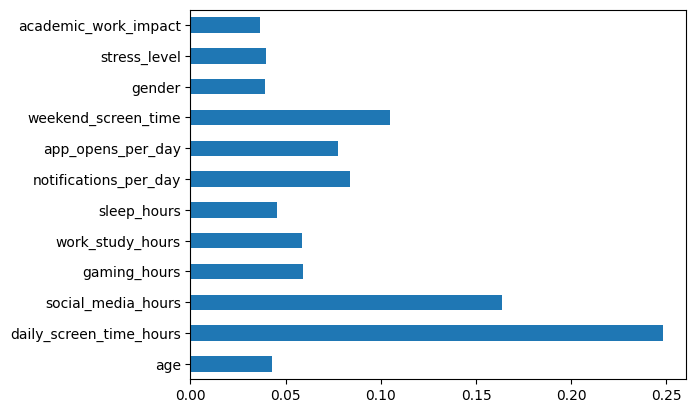

In [23]:
pd.Series(final_model.feature_importances_,index=X.columns).plot(kind='barh');

## Draft Session: 1h47m and No AUC (area under the ROC curve ) at All.

![](https://i.pinimg.com/236x/d5/1e/86/d51e86b7a45b4a336f5a1b26099ecb44.jpg)

#Acknowledgements:

Cold https://www.kaggle.com/code/maulikgajera/scroll-sleep-suffer-the-student-addiction-loop/notebook

Aryan_negi93 https://www.kaggle.com/code/aryannegi93/addiction-prediction-95-beats/notebook

Abhinab SM Chhetri https://www.kaggle.com/code/abhinabbudhachheri/s6e2-simple-eda/notebook

H-Z-Ning  https://www.kaggle.com/code/hzning/top-10-solution-0-97525-esay-is-all-you

mpwolke https://www.kaggle.com/code/mpwolke/plot-social-media-addiction/notebook